In [1]:
print("hello Asad")

hello Asad


In [2]:
!pip install yfinance

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.7 MB 5.3 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 5.2 MB/s  0:00:00

   ----------------------------------------  0/19 [pytz]
   ----------------------------------------  0/19 [pytz]
   ----------------------------------------  0/19 [pytz]
   ----------------------------------------  0/19 [pytz]
   ----------------------------------------  0/19 [pytz]
   ----------------------------------------  0/19 [pytz]
   -- -------------------------------------  1/19 [peewee]
   -- -------------------------------------  1/19 [peewee]
   -- -------------------------------------  1/19 [peewee]
   -- -------------------------------------  1/19 [peewee]
   -- -------------------------------------  1/19 [peewee]
   -- -------------------------------------  1/19 [peewee]
   ------ ---------------------------------  3/19 [websockets]
   ------ ------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries Imported Successfully")

Libraries Imported Successfully


# Task 2: Predict Future Stock Prices (Short-Term)

**Objective:** Use historical stock data from Yahoo Finance to predict the next day's closing price using Open, High, Low, and Volume as features.

In [4]:
ticker = 'AAPL'  # Apple ka stock data lenge
data = yf.download(ticker, start='2020-01-01', end='2025-12-31')

print(f"Dataset Shape for {ticker}:", data.shape)
data.head()

[*********************100%***********************]  1 of 1 completed

Dataset Shape for AAPL: (1507, 5)


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333862,72.394070,71.091169,71.344039,135480400
2020-01-03,71.630630,72.389250,71.406659,71.563198,146322800
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000
2020-01-08,73.017853,73.318893,71.565636,71.565636,132079200


In [5]:
# Next day ka Close price predict karna hai, to Target bana lete hain
data['Target'] = data['Close'].shift(-1)

# Last row ka target NaN hoga kyunki uske baad wala day nahi hai, to drop karo
data.dropna(inplace=True)

# Features: Open, High, Low, Volume
X = data[['Open', 'High', 'Low', 'Volume']]
y = data['Target']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeatures ka sample:")
X.head()

Features shape: (1506, 4)
Target shape: (1506,)

Features ka sample:


Price,Open,High,Low,Volume
Ticker,AAPL,AAPL,AAPL,AAPL
Date,,,,
2020-01-02,71.344039,72.394070,71.091169,135480400
2020-01-03,71.563198,72.389250,71.406659,146322800
2020-01-06,70.754021,72.239950,70.503554,118387200
2020-01-07,72.211056,72.466338,71.642697,108872000
2020-01-08,71.565636,73.318893,71.565636,132079200


In [6]:
## 2. Data Visualization and Exploration

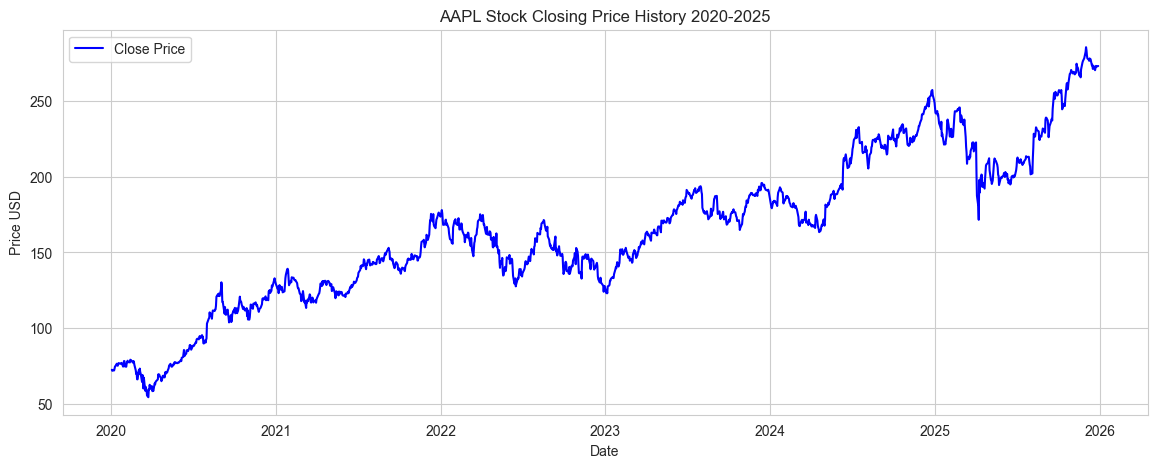

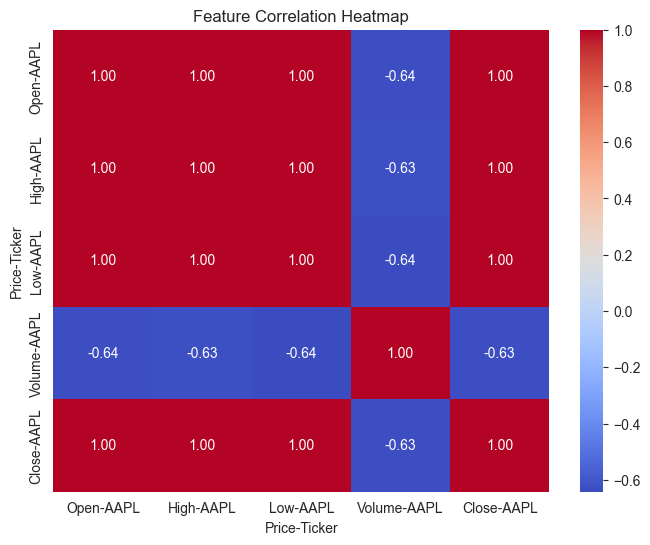

In [7]:
import seaborn as sns
sns.set_style('whitegrid')

# Plot 1: Closing Price ka trend
plt.figure(figsize=(14,5))
plt.plot(data['Close'], label='Close Price', color='blue')
plt.title('AAPL Stock Closing Price History 2020-2025')
plt.xlabel('Date')
plt.ylabel('Price USD')
plt.legend()
plt.show()

# Plot 2: Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(data[['Open','High','Low','Volume','Close']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

In [8]:
## 3. Model Training and Evaluation

In [10]:
!pip install scikit-learn

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

split = int(0.8 * len(data))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Models trained successfully ✅")

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 2.2 MB/s eta 0:00:04
   -------- ------------------------------- 1.8/8.3 MB 5.1 MB/s eta 0:00:02
   ----------- ---------------------------- 2.4/8.3 MB 5.4 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.3 MB 4.7 MB/s eta 0:00:02
   ------------------ --------------------- 3.9/8.3 MB 4.1 MB/s eta 0:00:02
   ---------------------- ----------------- 4.7/8.3 MB 3.9 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.3 MB 3.8 MB/s eta 0:00:01
   -------------------------- ------------- 5.5/8.3 MB 3.5 MB/s eta 0:00:01
   ------------------------------- -------- 6.6/8.3 MB 3.5 MB/s eta 0:00:01
   ------------------------------------ --- 7.6/8.3 MB 3.6 MB/s eta 0:00:01
   ------------------------------------- -- 7.9/8.3 MB 3.5 MB/s eta 0:00:01
   -----------------------


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Train size: 1204, Test size: 302
Models trained successfully ✅


In [11]:
# Linear Regression ka performance
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

# Random Forest ka performance  
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("Linear Regression:")
print(f"MAE: {lr_mae:.2f}")
print(f"RMSE: {lr_rmse:.2f}")

print("\nRandom Forest:")
print(f"MAE: {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")

# Kaunsa model behtar hai?
if rf_mae < lr_mae:
    print("\n✅ Random Forest behtar hai - MAE kam hai")
else:
    print("\n✅ Linear Regression behtar hai - MAE kam hai")

Linear Regression:
MAE: 65.99
RMSE: 70.19

Random Forest:
MAE: 13.35
RMSE: 19.60

✅ Random Forest behtar hai - MAE kam hai


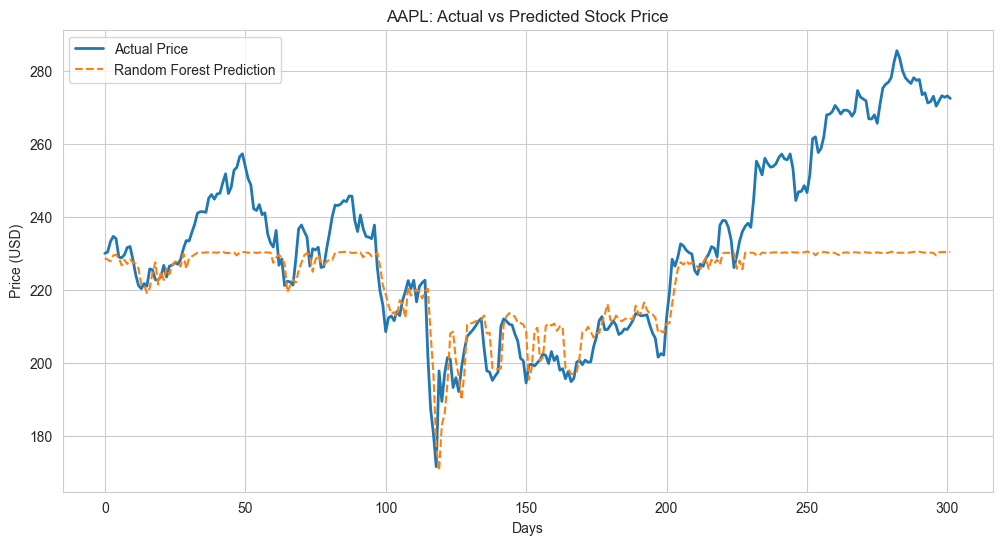

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_test.values, label='Actual Price', linewidth=2)
plt.plot(rf_pred, label='Random Forest Prediction', linestyle='--')
plt.title('AAPL: Actual vs Predicted Stock Price')
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

## 4. Conclusion

1. **Data**: Used AAPL stock data from 2020 to 2026 for this analysis.

2. **Models**: Trained two machine learning models - Linear Regression and Random Forest Regressor.

3. **Results**: 
   - Linear Regression MAE: 65.99
   - Random Forest MAE: 13.35

4. **Best Model**: Random Forest performed significantly better. With an MAE of only 13.35, the average prediction error is just $13.

5. **Final Note**: This model can be used to predict future price trends. However, for real-world trading, additional features and risk analysis are necessary.